# Prediction analysis

This is to analyse the predicted ages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# Load the predicted ages
results_df = pd.read_csv('column_model_predictions_all_subjects_with_cBAG.csv')

# Load metadata
METADATA_PATH = "../../../AD_DECODE_data3.xlsx"
metadata_df = pd.read_excel(METADATA_PATH, sheet_name='AD_DECODE_data2')
# Merge results with metadata by 'subject_id' in result_df and 'MRI_Exam' in metadata_df
# subject_id is like 02110
# MRI_Exam is like 2110
# Convert 'MRI_Exam' to match 'subject_id' format
metadata_df['subject_id'] = metadata_df['MRI_Exam'].apply(lambda x: f"{int(x):05d}" if pd.notnull(x) else np.nan)
# Ensure both subject_id columns are strings for merging
results_df['subject_id'] = results_df['subject_id'].apply(lambda x: f"{int(x):05d}")
# Merge the dataframes
merged_df = pd.merge(results_df, metadata_df, on='subject_id', how='left')

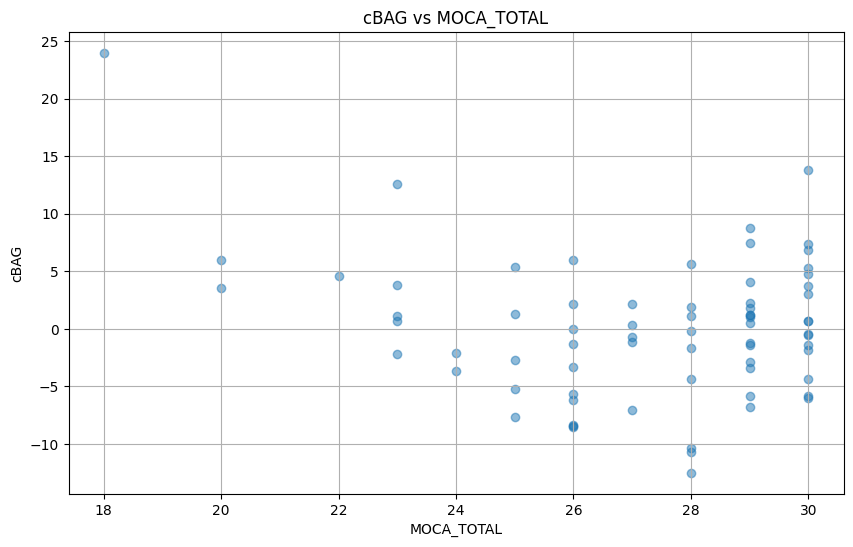

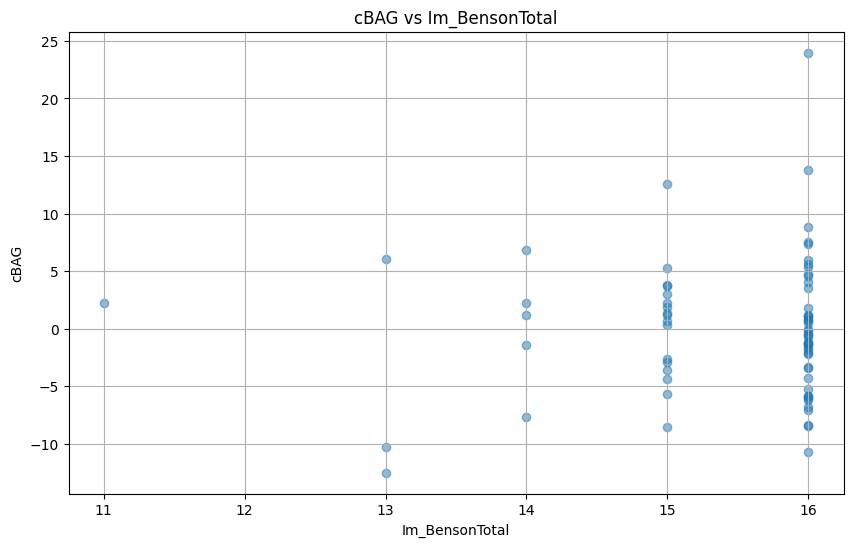

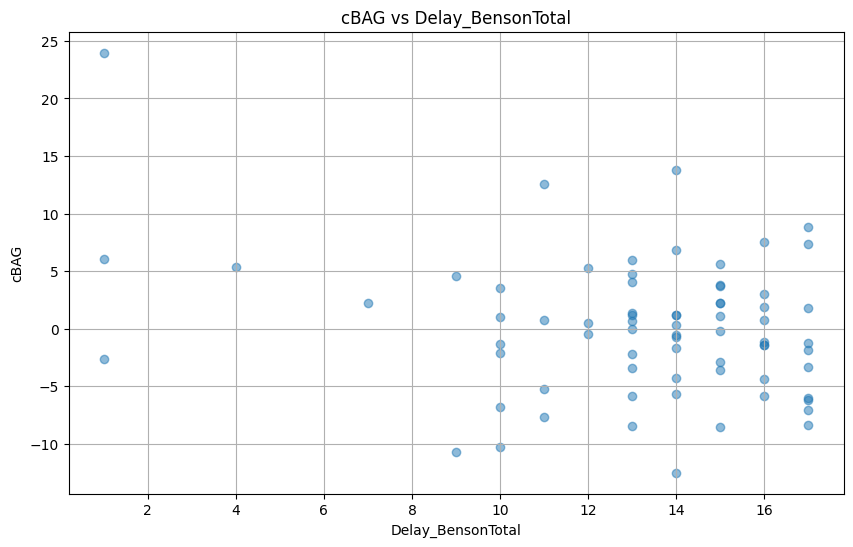

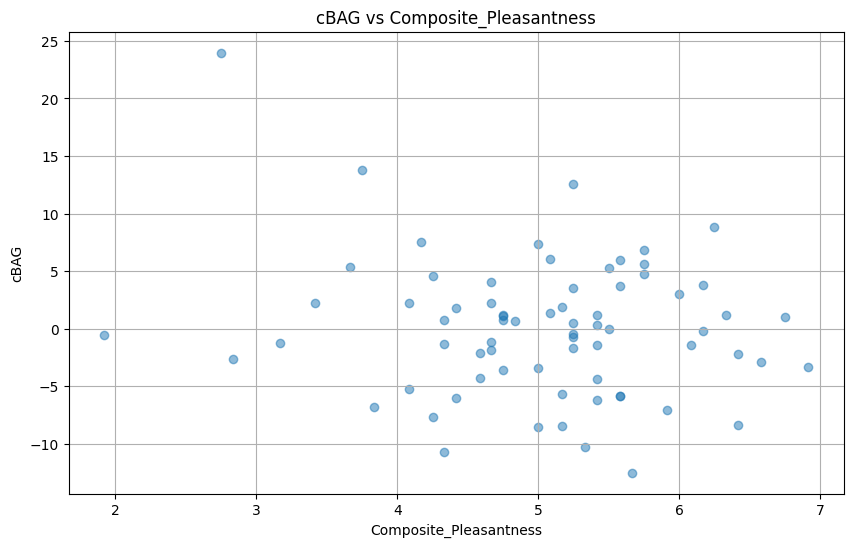

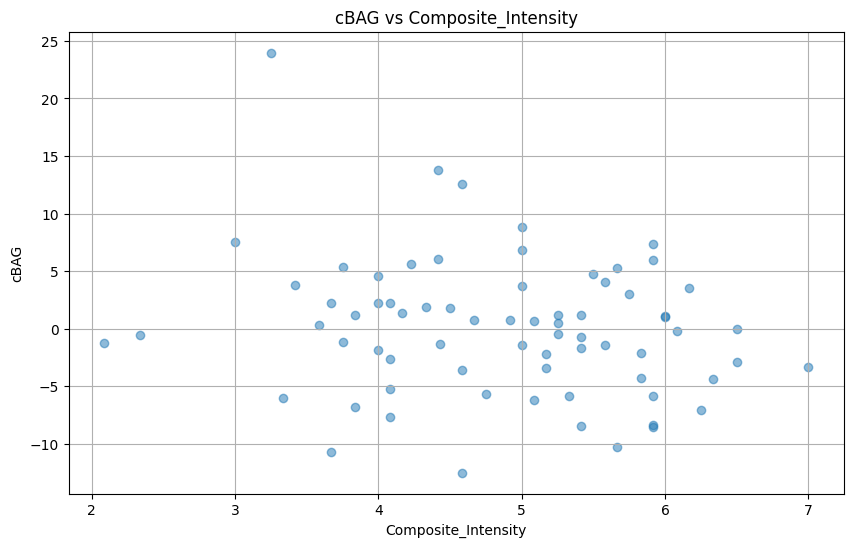

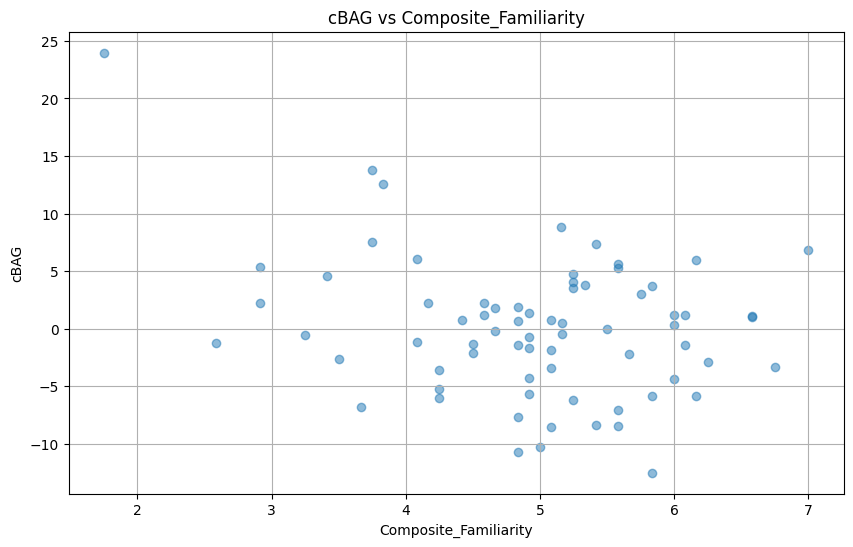

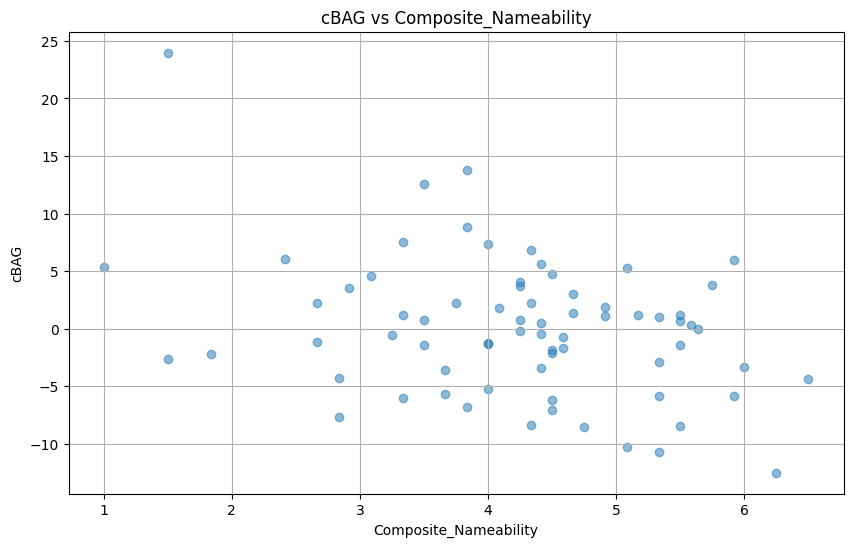

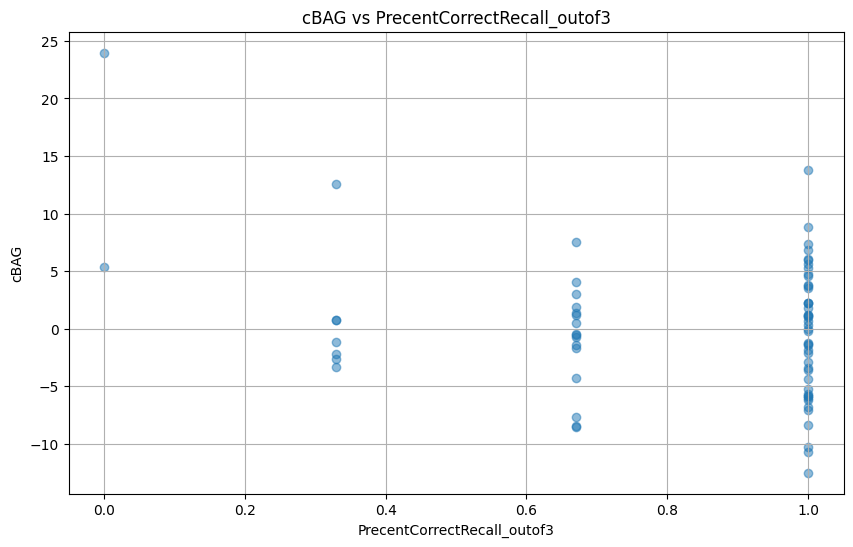

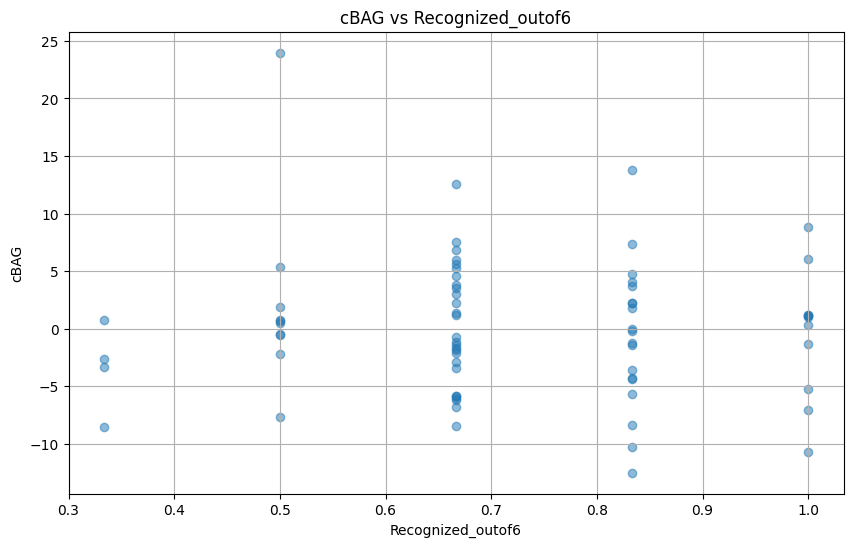

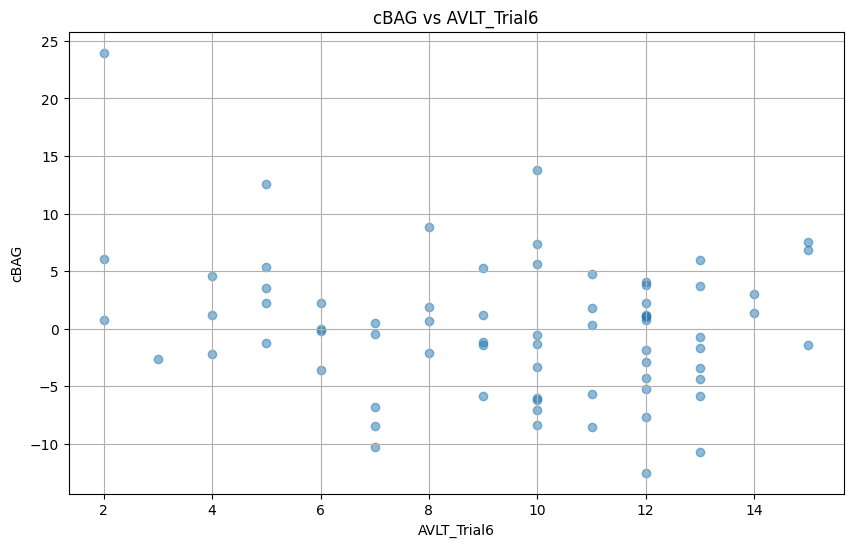

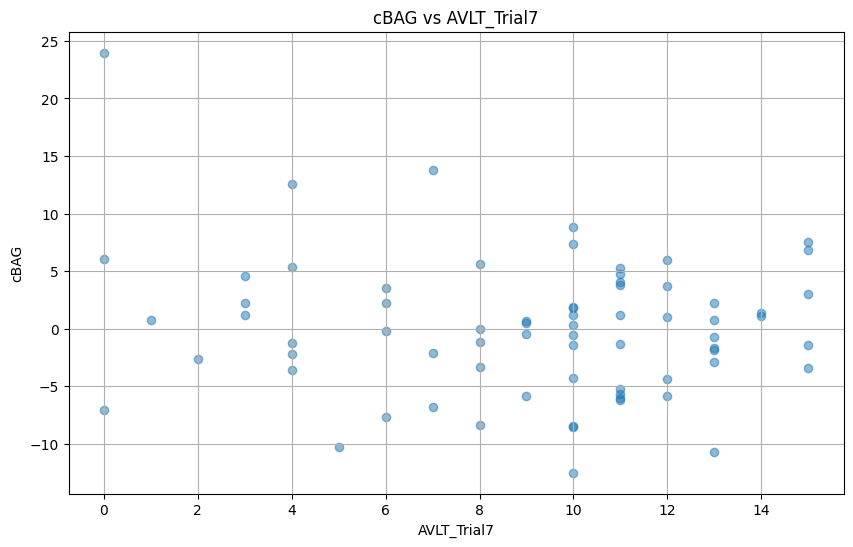

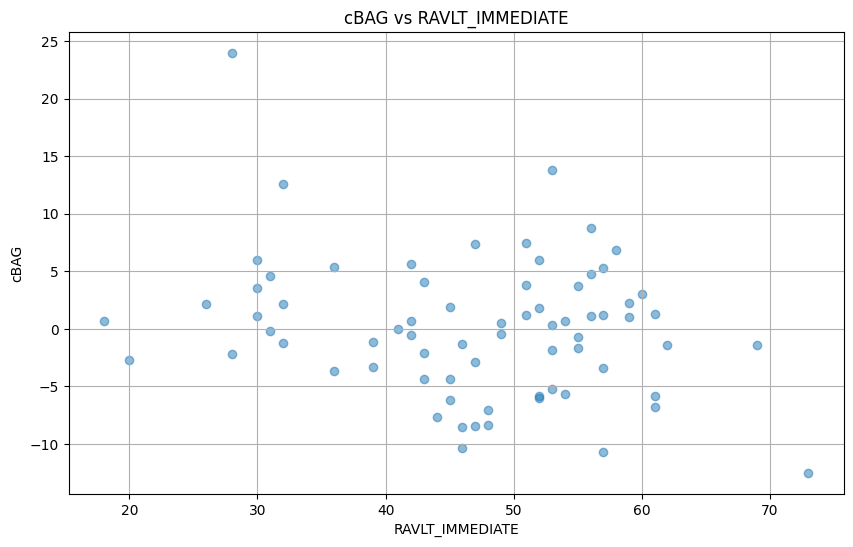

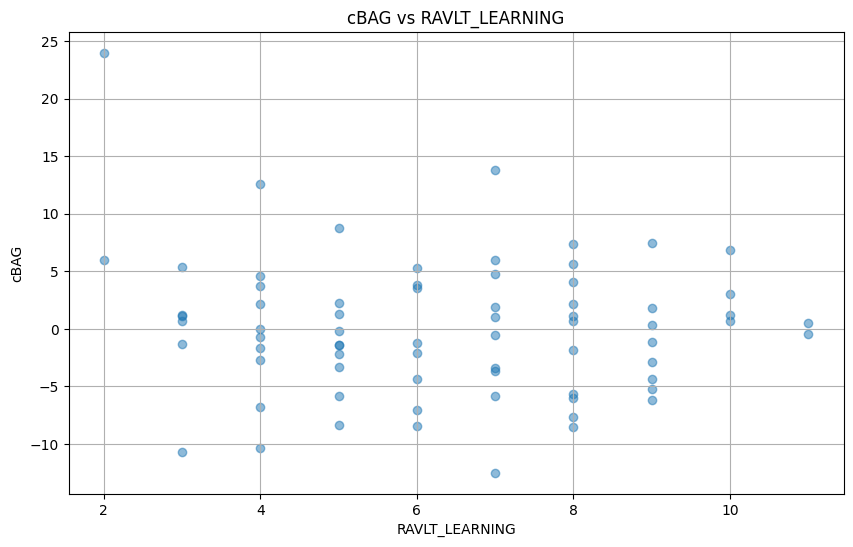

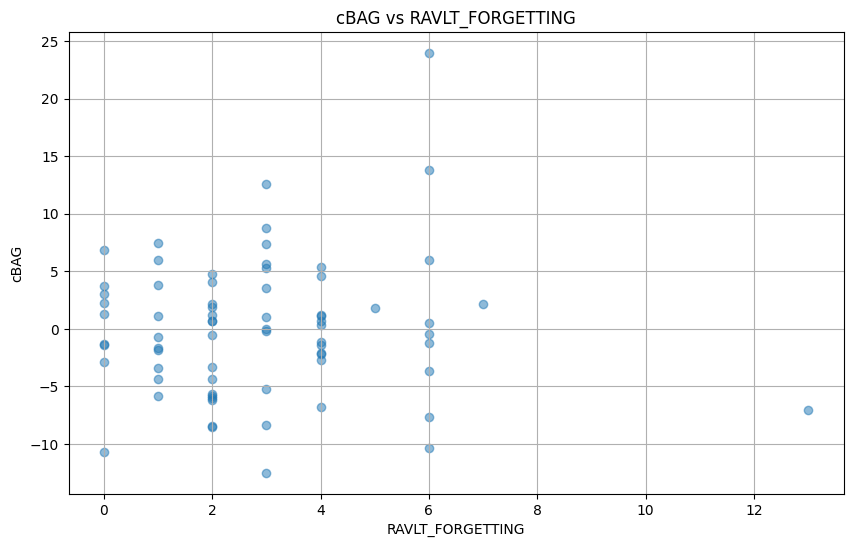

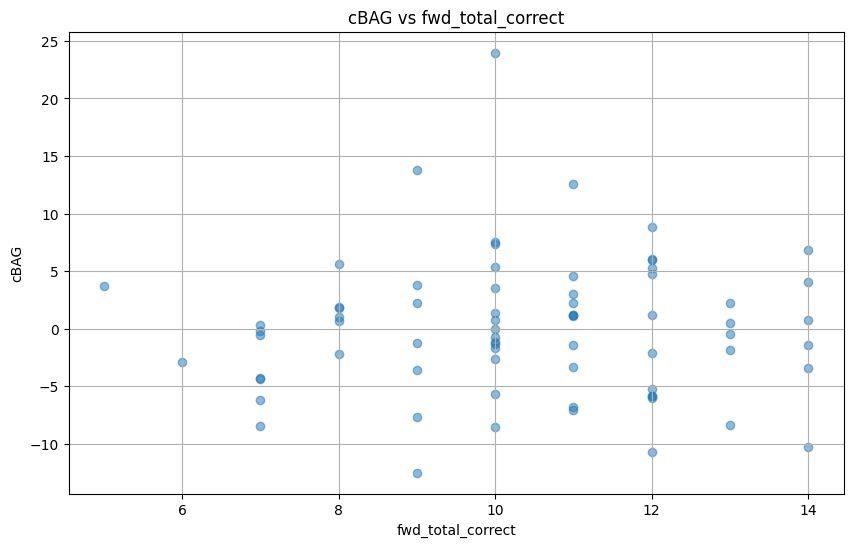

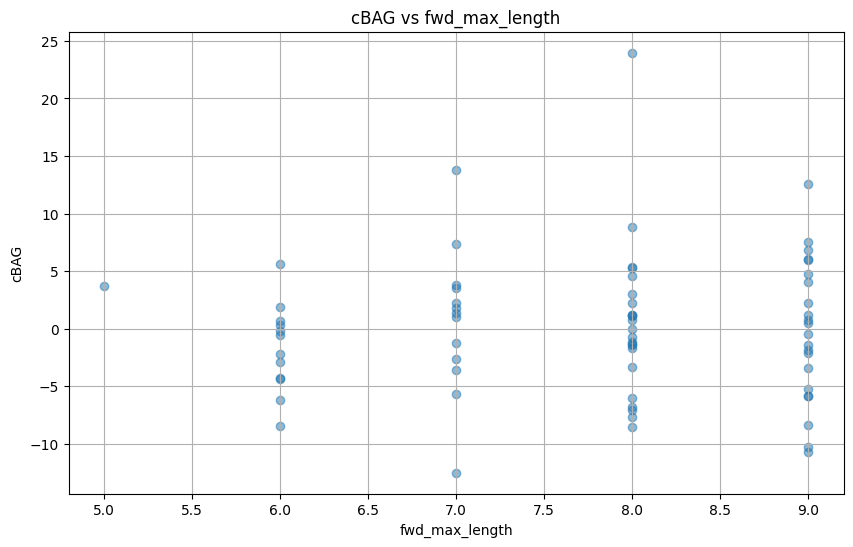

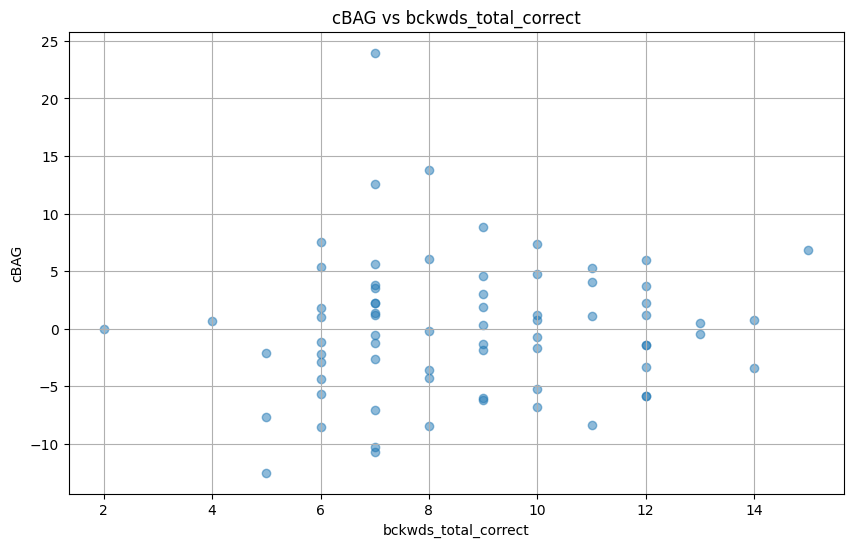

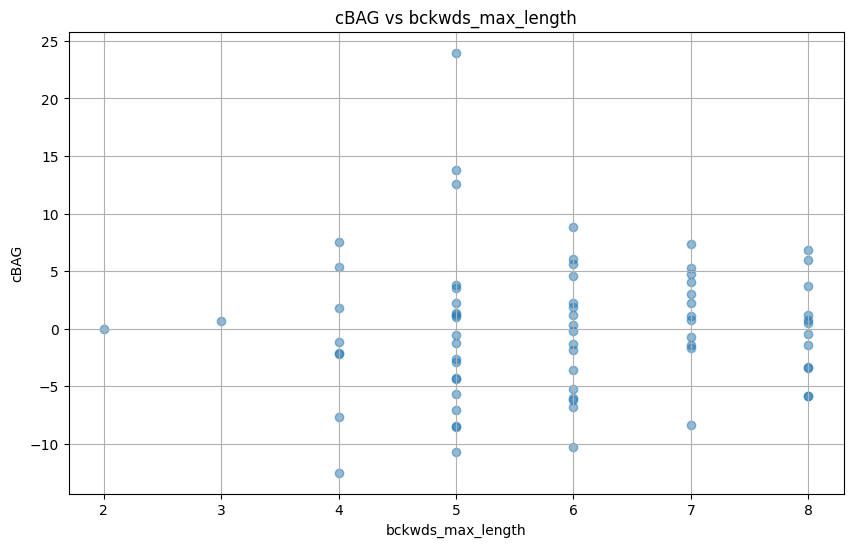

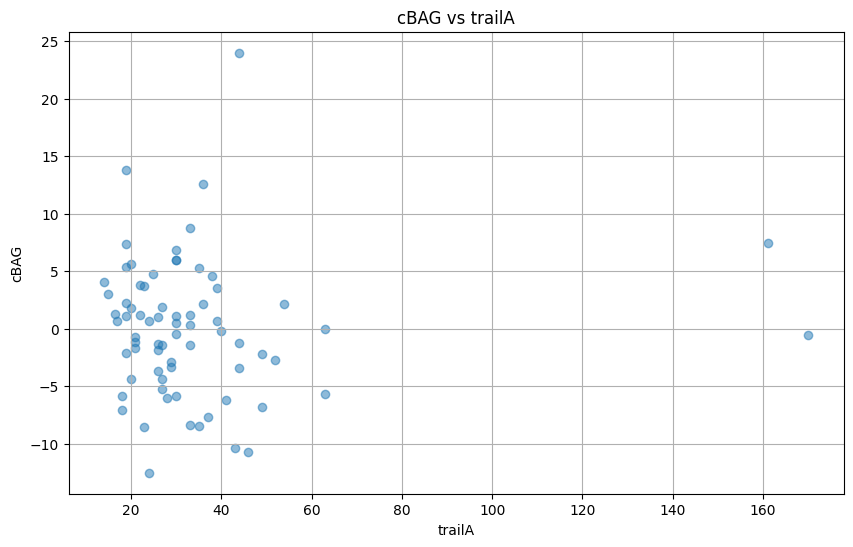

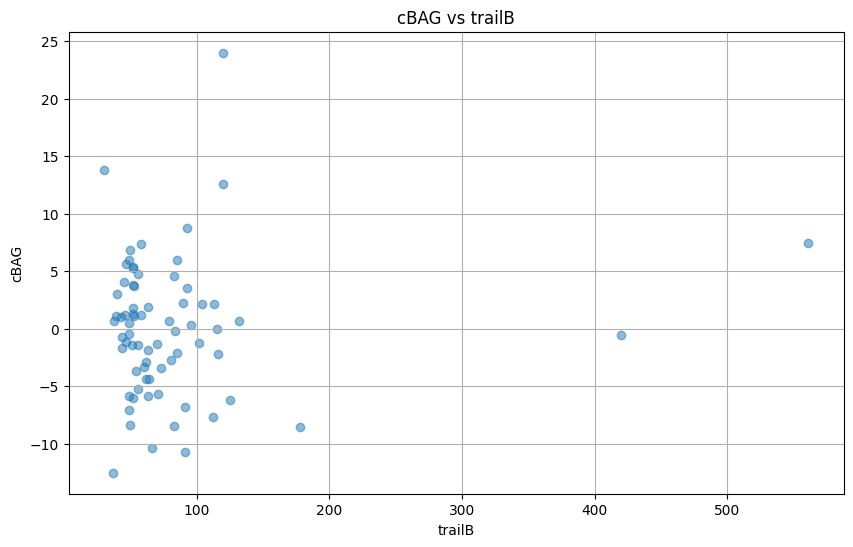

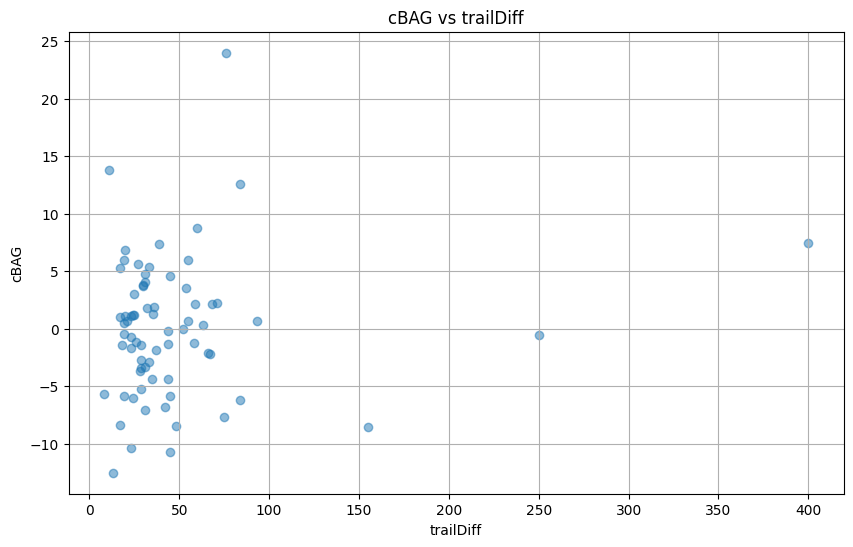

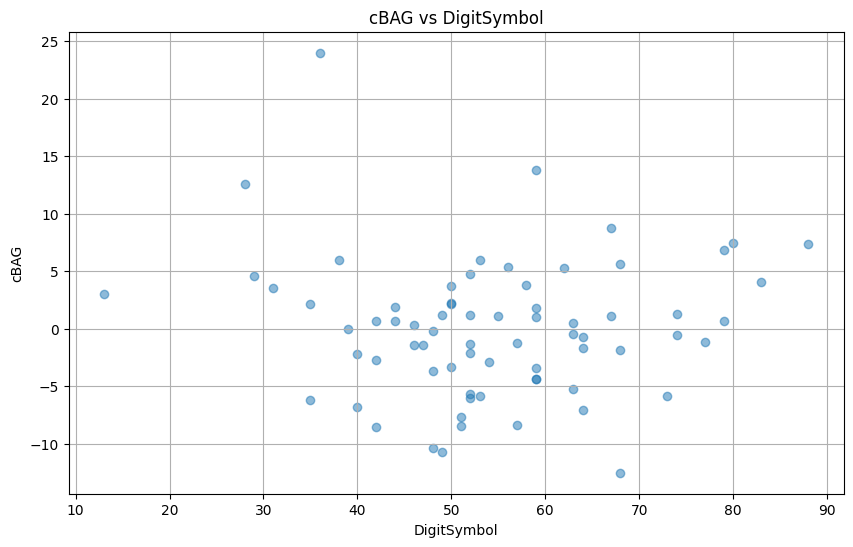

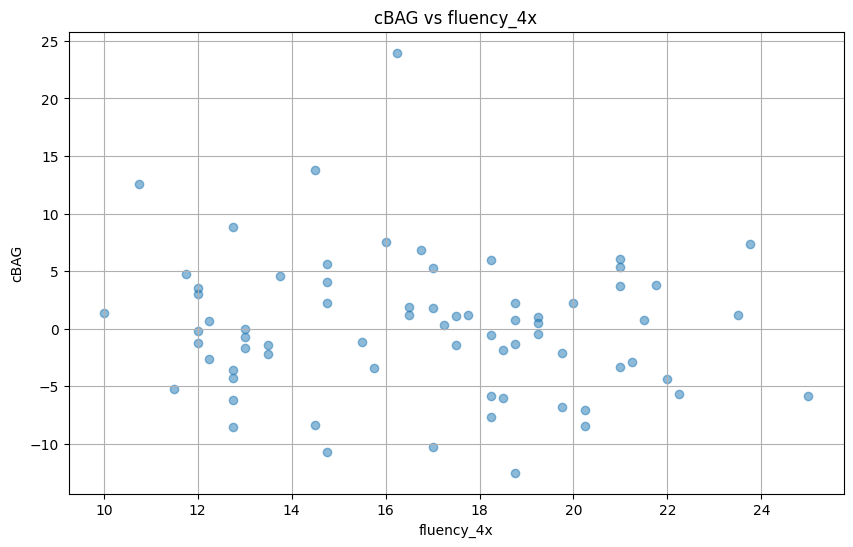

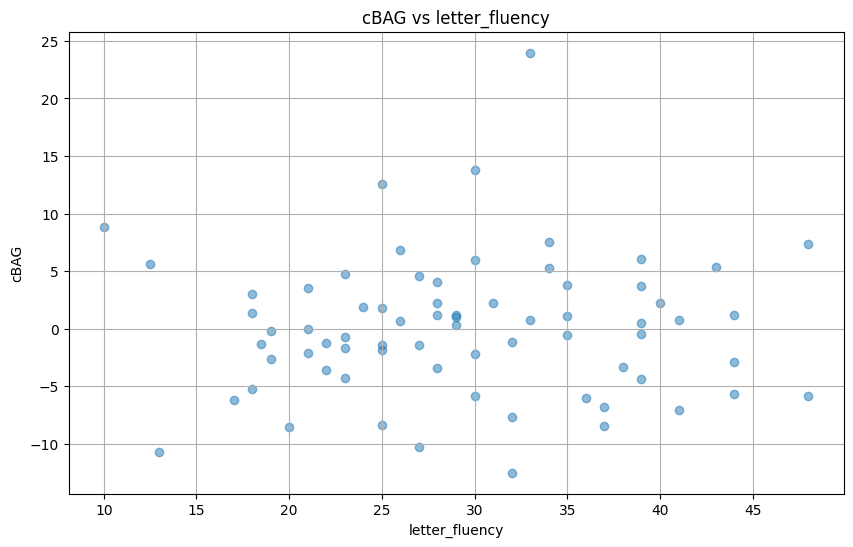

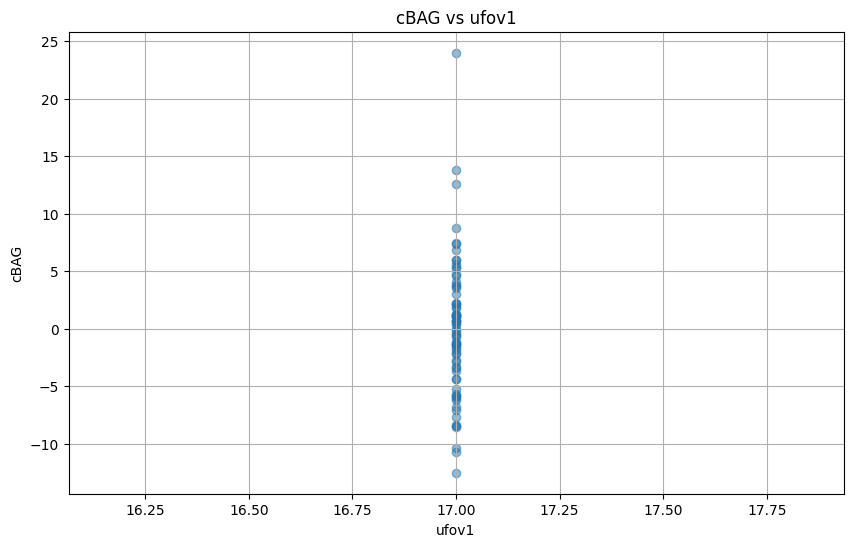

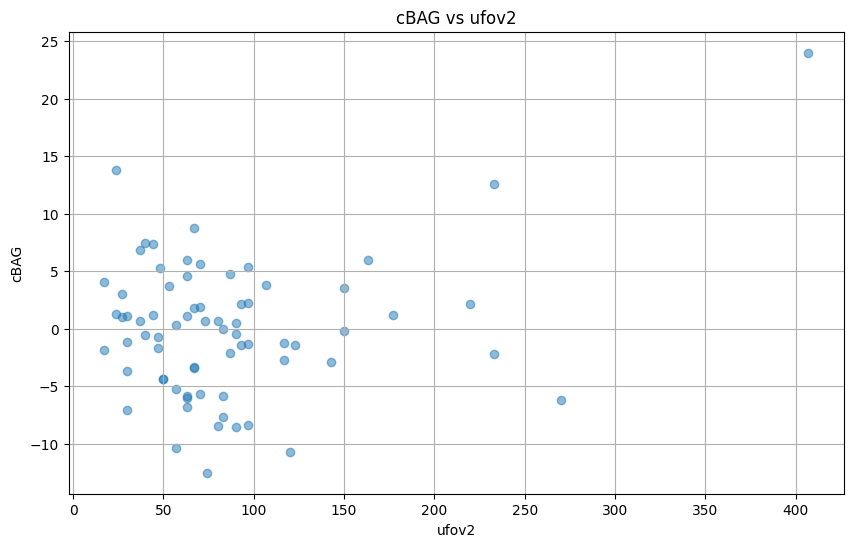

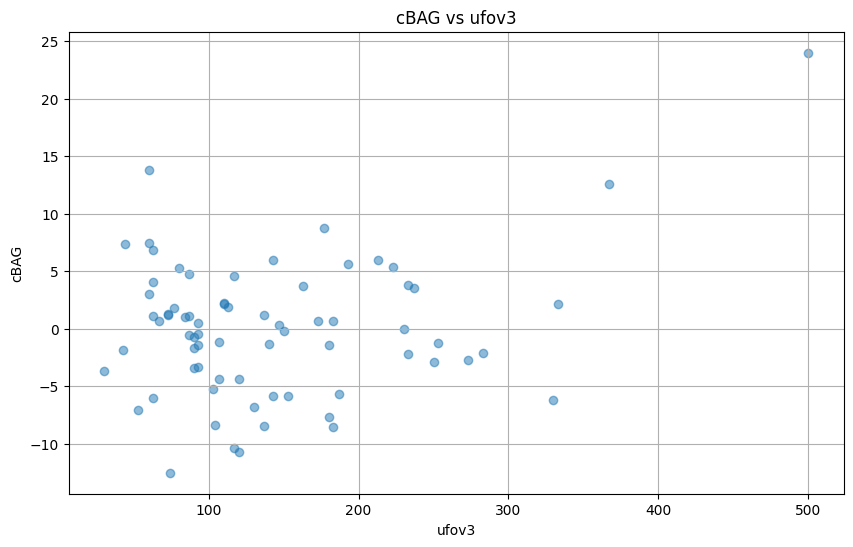

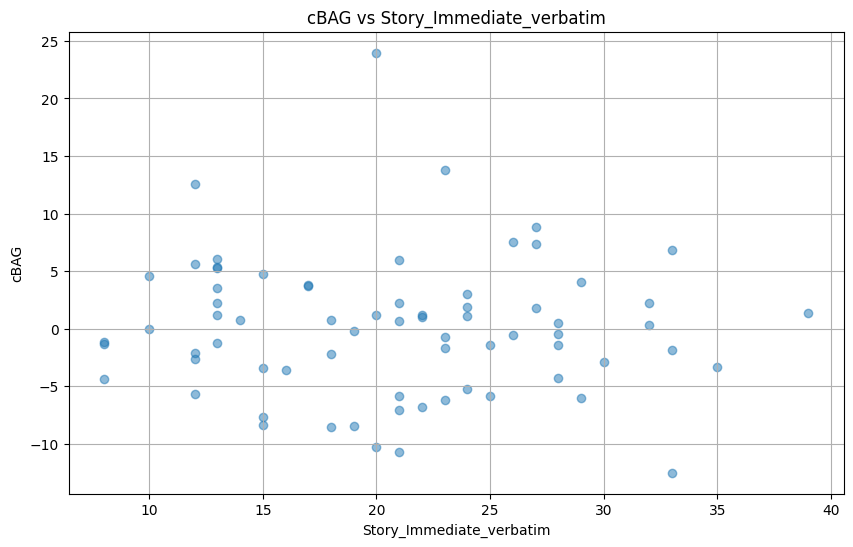

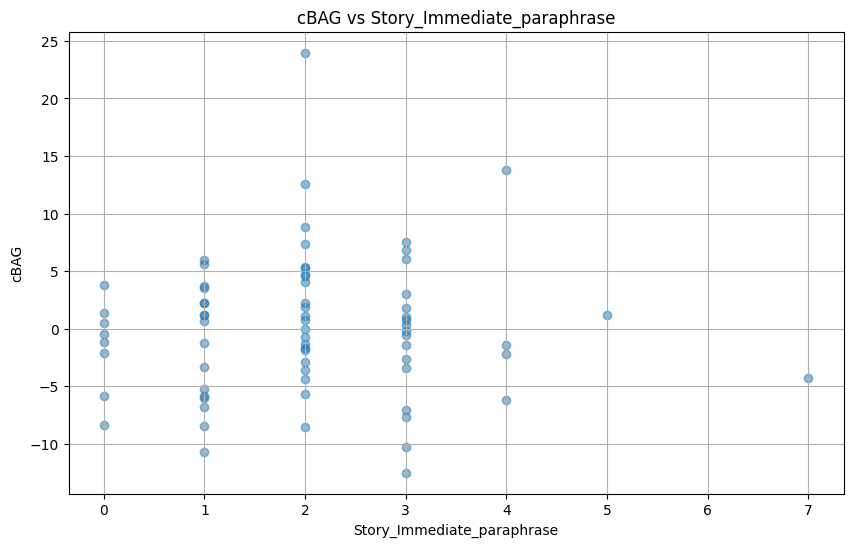

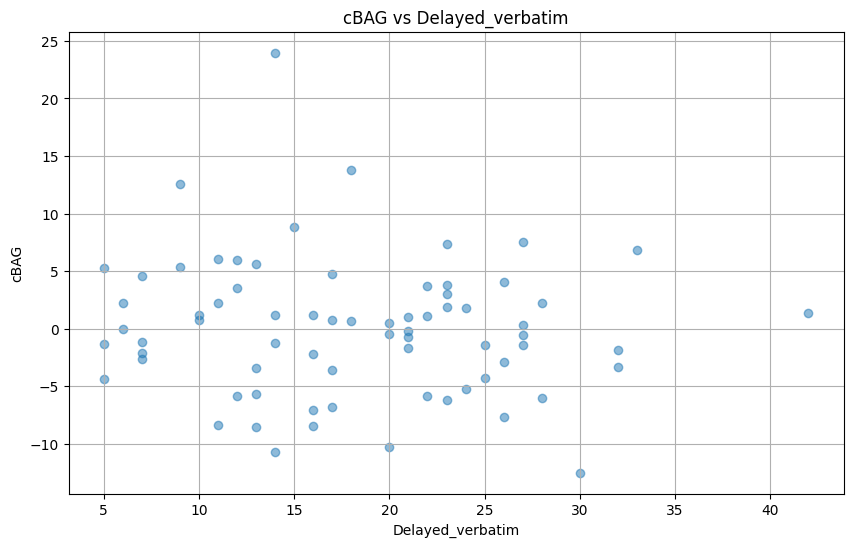

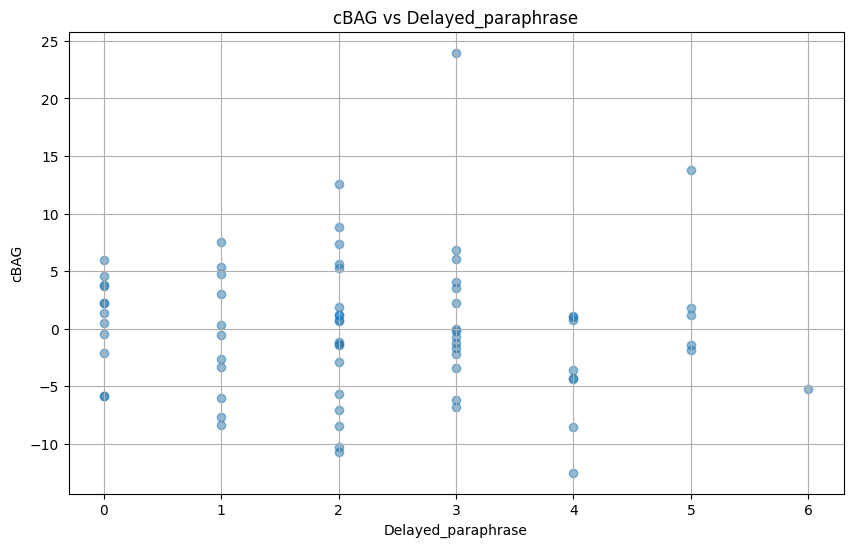

In [2]:
# Plot the cBAG vs column from 'MOCA_TOTAL' to 'Delayed_paraphrase'
cognitive_start = merged_df.columns.get_loc('MOCA_TOTAL')
cognitive_end = merged_df.columns.get_loc('Delayed_paraphrase') + 1
cognitive_columns = merged_df.columns[cognitive_start:cognitive_end]

for column in cognitive_columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df[column], merged_df['cBAG'], alpha=0.5)
    plt.title(f'cBAG vs {column}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.show()

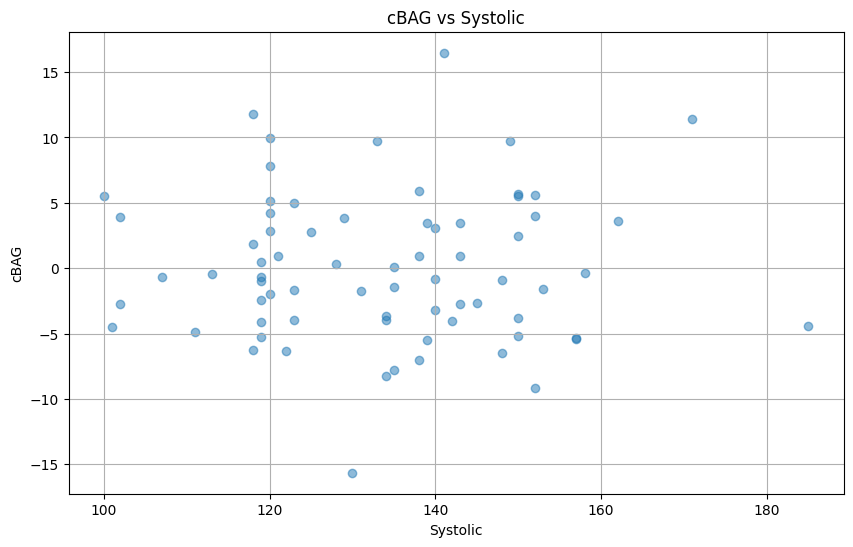

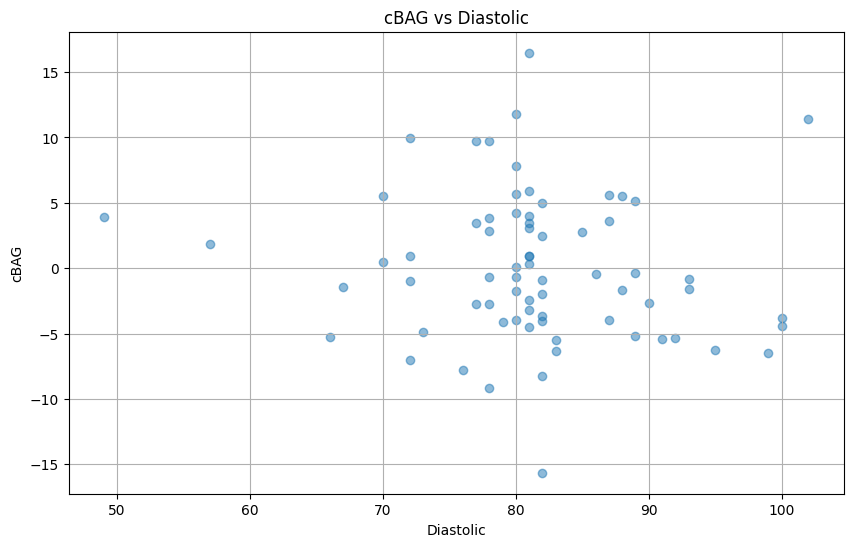

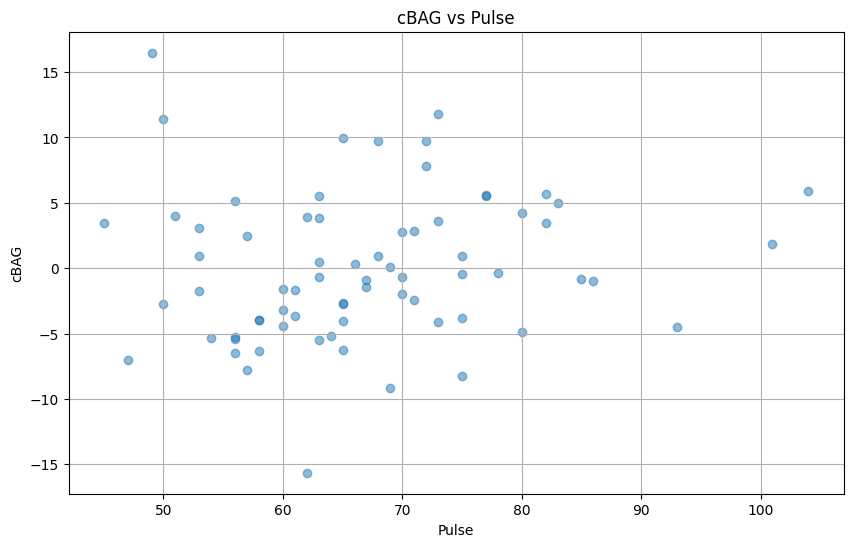

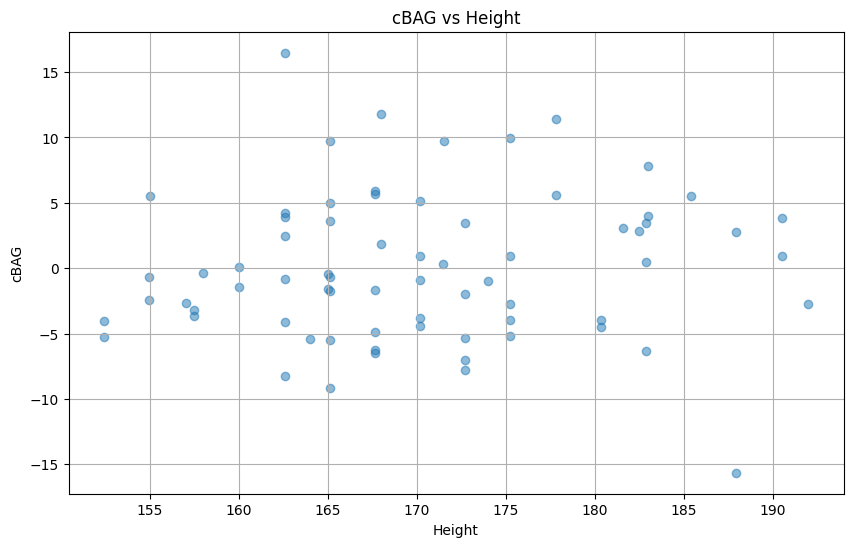

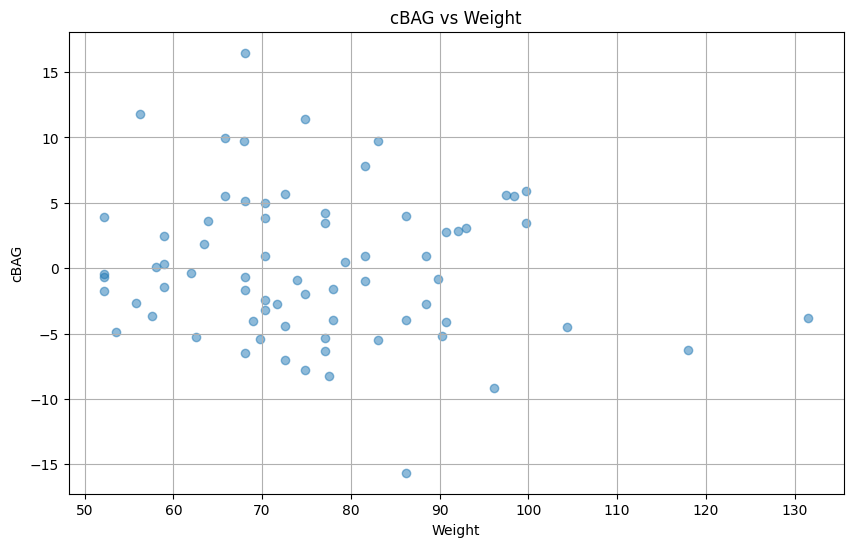

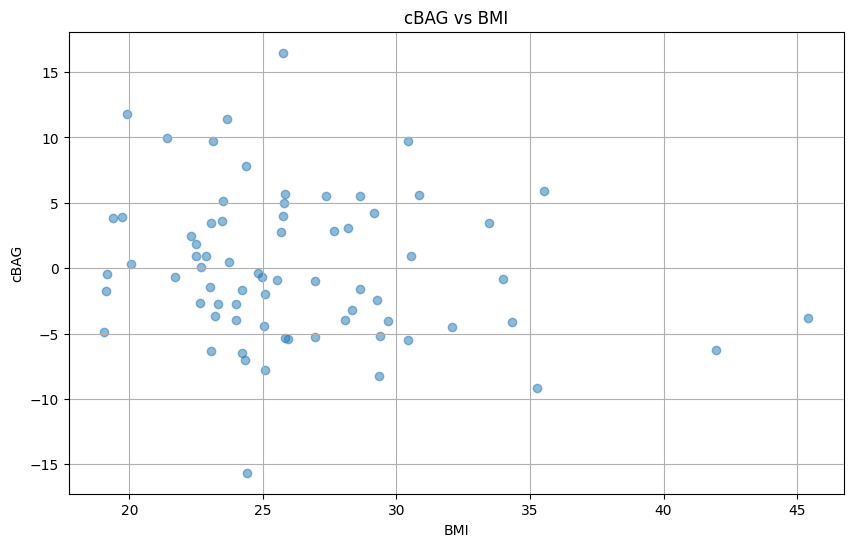

In [11]:
# Plot cbag vs biological metrics
biological_start = merged_df.columns.get_loc('Systolic')
biological_end = merged_df.columns.get_loc('BMI') + 1
biological_columns = merged_df.columns[biological_start:biological_end]
for column in biological_columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df[column], merged_df['cBAG'], alpha=0.5)
    plt.title(f'cBAG vs {column}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.show()

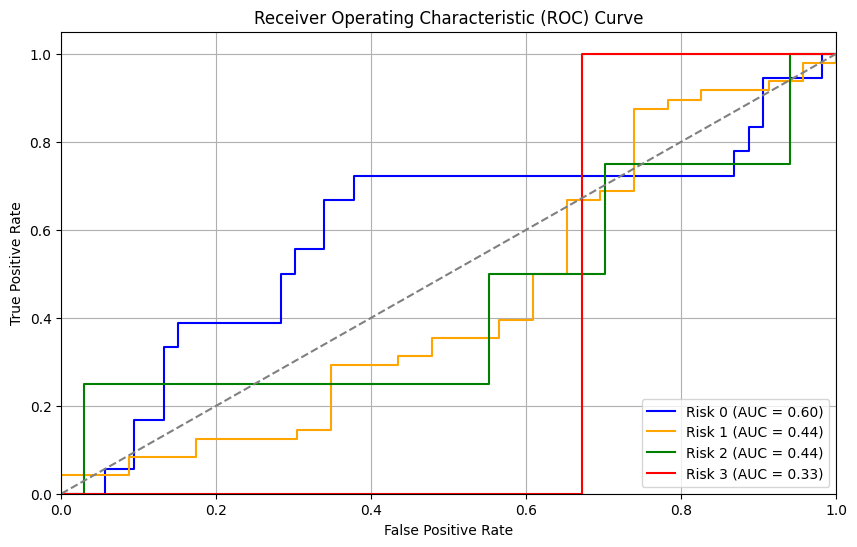

AUC for Risk Group 0: 0.5964360587002097
AUC for Risk Group 1: 0.44112318840579706
AUC for Risk Group 2: 0.44402985074626866
AUC for Risk Group 3: 0.3285714285714286


In [ ]:
# Group the sibjects into 2 groups by 'risk_for_ad'= 0 and 1 or 'risk_for_ad'= 2 and 3
risk_group_01 = merged_df[merged_df['risk_for_ad'].isin([0, 1])]
risk_group_23 = merged_df[merged_df['risk_for_ad'].isin([2, 3])]

# Plot the ROC curve by using cBAG to predict 'risk_for_ad'
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Binarize the 'risk_for_ad' column
y = label_binarize(merged_df['risk_for_ad'], classes=[0, 1, 2, 3])
# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}
for i in range(y.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y[:, i], merged_df['cBAG'])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr[0], tpr[0], color='blue', label='Risk 0 (AUC = {:.2f})'.format(roc_auc[0]))
plt.plot(fpr[1], tpr[1], color='orange', label='Risk 1 (AUC = {:.2f})'.format(roc_auc[1]))
plt.plot(fpr[2], tpr[2], color='green', label='Risk 2 (AUC = {:.2f})'.format(roc_auc[2]))
plt.plot(fpr[3], tpr[3], color='red', label='Risk 3 (AUC = {:.2f})'.format(roc_auc[3]))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print the AUC for each risk group
print("AUC for Risk Group 0:", roc_auc[0])
print("AUC for Risk Group 1:", roc_auc[1])
print("AUC for Risk Group 2:", roc_auc[2])
print("AUC for Risk Group 3:", roc_auc[3])


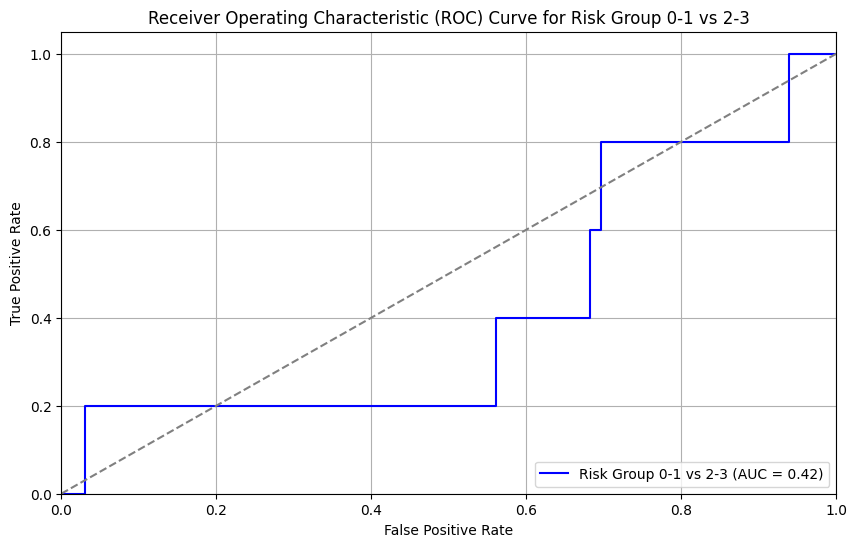

AUC for Risk Group 0-1 vs 2-3: 0.4181818181818182


In [ ]:
# Plot the ROC curve by using cBAG to predict group 0 and 1 vs group 2 and 3
y_risk_group = label_binarize(merged_df['risk_for_ad'].apply(lambda x: 0 if x in [0, 1] else 1), classes=[0, 1])
fpr_risk_group, tpr_risk_group, _ = roc_curve(y_risk_group, merged_df['cBAG'])
roc_auc_risk_group = auc(fpr_risk_group, tpr_risk_group)
# Plot ROC curve for risk group 0 and 1 vs group 2 and 3
plt.figure(figsize=(10, 6))
plt.plot(fpr_risk_group, tpr_risk_group, color='blue', label='Risk Group 0-1 vs 2-3 (AUC = {:.2f})'.format(roc_auc_risk_group))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Risk Group 0-1 vs 2-3')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print the AUC for risk group 0-1 vs 2-3
print("AUC for Risk Group 0-1 vs 2-3:", roc_auc_risk_group)
